# Advanced topics

This notebook covers advanced features of NiSpace:

**Individual-level colocalization** — compute colocalization for each subject separately.  
**Individual-level deviation colocalization** — compute colocalization for each subject separately using z-score maps.  
**Dimensionality reduction** (`reduce_x()`) — summarize a large set of reference maps into a smaller number of components before colocalization.  
**Alternative colocalization methods** — partial correlation, PLS, ridge regression, and more.  

We use the ENIGMA reference datasets (`enigmathick` and `enigmaarea`) as our input maps here — these contain published cortical thickness and surface area effect sizes (Cohen's d) for many psychiatric disorders vs. healthy controls. Note that we're using *reference* data as our input maps, which, in the case of ENIGMA maps, is however often done: it lets us ask questions like "which reference systems explain patterns of grey matter alterations across psychiatric disorders?"

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

In [3]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.api import NiSpace

# ENIGMA cortical thickness effect sizes (Cohen's d, cases vs. controls)
# These are reference datasets — we use them as target maps (Y) here
enigma_thick = fetch_reference("enigmathick", parcellation="DesikanKilliany", collection="Main",
                               print_references=False)
print(f"ENIGMA thickness: {enigma_thick.shape[0]} disorders x {enigma_thick.shape[1]} cortical parcels")
print("Disorders:", list(enigma_thick.index))

# Continuous resting-state network (RSN) reference maps for colocalization: dataset rsn17
rsn17_maps = fetch_reference("rsn17", parcellation="DesikanKilliany",
                             print_references=False)
print(f"RSN (Kong 17 networks): {rsn17_maps.shape[0]} maps x {rsn17_maps.shape[1]} parcels")

INFO | 20/07/26 18:25:53 | nispace.datasets: Loading enigmathick maps.


INFO | 20/07/26 18:25:53 | nispace.datasets: Loading integrated collection 'Main' for dataset 'enigmathick'.


INFO | 20/07/26 18:25:53 | nispace.datasets: Filtering maps by collection.


INFO | 20/07/26 18:25:53 | nispace.datasets: Loading data parcellated with 'DesikanKilliany'


ENIGMA thickness: 16 disorders x 68 cortical parcels
Disorders: [('dx-mdd_age-adult_pub-schmaal2017',), ('dx-adhd_age-allages_pub-hoogman2019',), ('dx-asd_pub-vanrooij2018',), ('dx-bd_age-adult_pub-hibar2018',), ('dx-scz_pub-vanerp2018',), ('dx-ocd_age-adult_pub-boedhoe2018',), ('dx-epilepsy_pub-whelan2018',), ('dx-epilepsy_subtype-gge_pub-whelan2018',), ('dx-epilepsy_subtype-ltle_pub-whelan2018',), ('dx-epilepsy_subtype-rtle_pub-whelan2018',), ('dx-22q_pub-sun2020',), ('dx-an_pub-walton2022',), ('dx-an_subtype-acAN_pub-walton2022',), ('dx-an_subtype-pwrAN_pub-walton2022',), ('dx-antisocial_pub-gao2024',), ('dx-pd_pub-laansma2021',)]
INFO | 20/07/26 18:25:53 | nispace.datasets: Loading rsn17 maps.


INFO | 20/07/26 18:25:53 | nispace.datasets: Loading data parcellated with 'DesikanKilliany'


RSN (Kong 17 networks): 17 maps x 68 parcels


## Individual-level colocalization

The ENIGMA dataset gives us effect size maps for multiple disorders simultaneously. We can test all disorders at once by passing the full DataFrame as `y`.

In [4]:
nsp = NiSpace(
    x=rsn17_maps,
    y=enigma_thick,   # all 22 disorder maps as input
    parcellation="DesikanKilliany",
    seed=42,
    n_proc=4
)
nsp.fit()
nsp.colocalize("spearman")
nsp.permute("maps", n_perm=1000)
nsp.correct_p()

colocs = nsp.get_colocalizations()
print(f"Result: {colocs.shape[0]} disorders x {colocs.shape[1]} receptors")
p_values = nsp.get_p_values()
print(f"Result: {p_values.shape[0]} x {p_values.shape[1]} receptors")

INFO | 20/07/26 18:25:53 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 20/07/26 18:25:53 | nispace.core.parcellation: Building cortex Parcellation for 'DesikanKilliany' from library. DOI: 10.1016/j.neuroimage.2006.01.021


INFO | 20/07/26 18:25:53 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:25:53 | nispace.core.parcellation: Parcellation 'DesikanKilliany': validation passed.


INFO | 20/07/26 18:25:53 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):


...

INFO | 20/07/26 18:25:58 | nispace.core.permute: Z-standardizing null maps.


Processing null arrays (4 proc): 100%|█████████████████████████████████████████████| 1000/1000 [00:01<00:00, 974.84it/s]

Null colocalizations (spearman, 4 proc): 100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 7867.45it/s]

INFO | 20/07/26 18:25:59 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


Result: 16 disorders x 17 receptors
Result: 1 x 17 receptors


If we plot these data now with the automated method, what was bars before are now scatter points. Each point represents one ENIGMA cortical effect size map, respectively the disorder map's association to each reference map.  
We, by default calculate only one p value for the group-average, which here tests if there is a spatial pattern consistenly associated with ENIGMA maps *across* disorders.

INFO | 20/07/26 18:26:00 | nispace.plotting: Significance annotation: 2/17 p_uncorrected < 0.05, 1/17 p_meffgalwey < 0.05


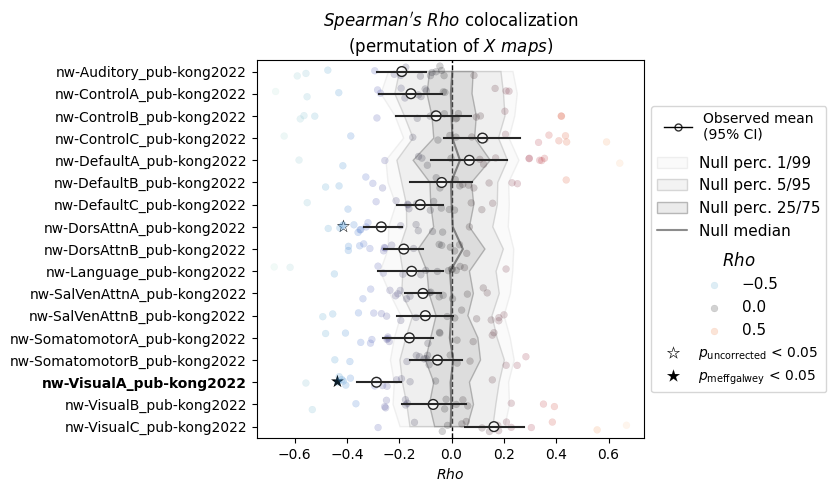

(<Figure size 500x490 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x1726adcd0>)

In [5]:
# plot all disorders
nsp.plot(sort_by="p")

That is interesting in itself. But we might now want to know how each individual ENIGMA map colocalizes with each individual resting-state network.  

To achieve that, we can set a flag in `NiSpace.permute()`, which deactivates the group-level p value computation.

In [6]:
nsp.colocalize("spearman")
nsp.permute("maps", n_perm=1000, p_from_average_y_coloc=False)
nsp.correct_p()

# both the colocalization and the p value dataframes will now be a n_reference x n_enigma dataframe
colocs = nsp.get_colocalizations()
print(f"Colocalizations: {colocs.shape[0]} disorders x {colocs.shape[1]} receptors")
p_values = nsp.get_p_values()
pc_values = nsp.get_corrected_p_values()
print(f"P-Values: {p_values.shape[0]} disorders x {p_values.shape[1]} receptors")

Colocalizing (spearman, 4 proc): 100%|████████████████████████████████████████████████| 16/16 [00:00<00:00, 1460.51it/s]

INFO | 20/07/26 18:26:00 | nispace.core.permute: Found existing null maps.


INFO | 20/07/26 18:26:00 | nispace.core.permute: Z-standardizing null maps.


Processing null arrays (4 proc): 100%|████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8255.06it/s]

Null colocalizations (spearman, 4 proc): 100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 7780.76it/s]

INFO | 20/07/26 18:26:00 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


Colocalizations: 16 disorders x 17 receptors
P-Values: 16 disorders x 17 receptors


A heatmap is a typical means to visualize this. For now, we just use `seaborn.heatmap()` and add the p values as annotation.

<Axes: xlabel='map', ylabel='map'>

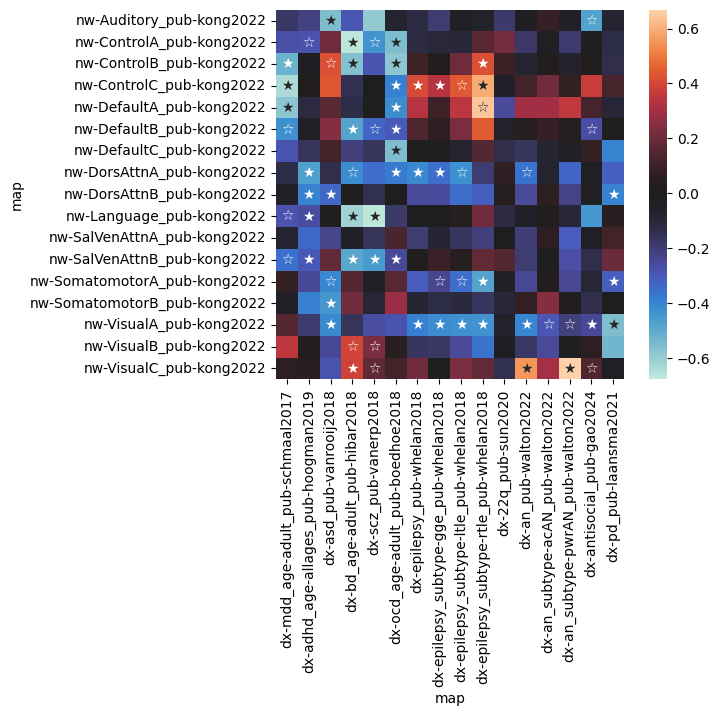

In [7]:
import seaborn as sns

sns.heatmap(
    colocs.T,
    center=0,
    square=True,
    annot=((p_values.T < 0.05).astype(int) + (pc_values.T.astype(int) < 0.05)) \
        .replace({0: "", 1: "☆", 2: "★"}),
    fmt="s"
)

## Individual-level deviation colocalization

Except for the last, the analyses so far have produced group-level results: one colocalization value per disorder or condition. But we often may want to compute colocalization for each subject individually.

The `"zscore(a,b)"` transform in `transform_y()` produces one deviation map per subject in group A (patients). We can then colocalize each map separately and look at the distribution across subjects.

This is particularly useful for stratifying patients by their colocalization profile (e.g., identifying subgroups with different neurotransmitter involvement).

We return to the anorexia nervosa example dataset here — as a reminder, it is **simulated** and not intended for scientific use.

In [8]:
from nispace.datasets import fetch_example

an_data = fetch_example("anorexianervosa", parcellation="Yan200")
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

pet_s200 = fetch_reference("pet", parcellation="Yan200",
                           collection="UniqueTracers", print_references=False)

nsp_indiv = NiSpace(
    x=pet_s200,
    y=an_data,
    parcellation="Yan200",
    seed=42,
    n_proc=4
)
nsp_indiv.fit()

# compute z-scores: each AN patient mapped relative to HC mean and SD
nsp_indiv.transform_y("zscore(a,b)", groups=groups)

print(f"Individual z-score maps: {nsp_indiv.get_y().shape}")

INFO | 20/07/26 18:26:01 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Yan200.


INFO | 20/07/26 18:26:01 | nispace.datasets: Loading pet maps.


INFO | 20/07/26 18:26:01 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 20/07/26 18:26:01 | nispace.datasets: Filtering maps by collection.


INFO | 20/07/26 18:26:01 | nispace.datasets: Loading data parcellated with 'Yan200'


...

INFO | 20/07/26 18:26:02 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:26:02 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


WARNING | 20/07/26 18:26:02 | nispace.io: Parcellated data contains nan values!


INFO | 20/07/26 18:26:02 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


Individual z-score maps: (50, 200)


In [9]:
# colocalize each subject's z-score map with PET maps
nsp_indiv.colocalize("spearman")

# result: one row per AN subject, one column per receptor
indiv_colocs = nsp_indiv.get_colocalizations()
print(f"Individual colocalizations: {indiv_colocs.shape}")
indiv_colocs.head(5)

Colocalizing (spearman, 4 proc): 100%|████████████████████████████████████████████████| 50/50 [00:00<00:00, 2449.69it/s]

Individual colocalizations: (50, 29)


set                                                      General  \
map       target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
sub-001AN                                          -0.092801       
sub-002AN                                          -0.034211       
sub-003AN                                           0.128289       
sub-004AN                                          -0.017879       
sub-005AN                                           0.063341       

set                                                            \
map       target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
sub-001AN                                          -0.139145    
sub-002AN                                           0.026949    
sub-003AN                                           0.037643    
sub-004AN                                          -0.108614    
sub-005AN                                          -0.070749    

set                                                           \
map       target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
sub-001AN                                          -0.099534   
sub-002AN                                          -0.019551   
sub-003AN                                           0.078281   
sub-004AN                                          -0.061209   
sub-005AN                                           0.085257   

set                                                             \
map       target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
sub-001AN                                          -0.099192     
sub-002AN                                          -0.051041     
sub-003AN                                           0.156557     
sub-004AN                                          -0.044154     
sub-005AN                                           0.061179     

set                                                           \
map       target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
sub-001AN                                          -0.100787   
sub-002AN                                          -0.053727   
sub-003AN                                           0.021494   
sub-004AN                                          -0.060982   
sub-005AN                                           0.092429   

set                                              Immunity  \
map       target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
sub-001AN                                       -0.121601   
sub-002AN                                       -0.109795   
sub-003AN                                        0.008889   
sub-004AN                                        0.013888   
sub-005AN                                        0.030433   

set                                                       \
map       target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
sub-001AN                                       0.023633   
sub-002AN                                      -0.029288   
sub-003AN                                       0.068417   
sub-004AN                                      -0.112908   
sub-005AN                                      -0.080497   

set                                                  Glutamate  \
map       target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
sub-001AN                                          -0.084197     
sub-002AN                                          -0.018089     
sub-003AN                                           0.081357     
sub-004AN                                          -0.047852     
sub-005AN                                           0.112793     

set                                                            \
map       target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
sub-001AN                                          -0.141287    
sub-002AN                                          -0.034735    
sub-003AN                                           0.019581    
sub-004AN                                          -0.025143    
sub-

In [10]:
# for permutation testing with individual maps, we permute group labels
# p values are computed for the MEAN colocalization across subjects by default
#  -> compare to the section above
nsp_indiv.permute("groups", groups=groups, n_perm=1000)
nsp_indiv.correct_p()
p_indiv = nsp_indiv.get_p_values()

print(f"P-values shape: {p_indiv.shape}")
print(p_indiv.T.sort_values(by=p_indiv.index[0]).head(10))

INFO | 20/07/26 18:26:02 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


Permuting groups (4 proc): 100%|████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 571119.83it/s]

Null transformations (spearman, 4 proc): 100%|███████████████████████████████████| 1000/1000 [00:00<00:00, 13600.65it/s]

Processing null arrays (4 proc): 100%|████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6388.56it/s]

Null colocalizations (spearman, 4 proc): 100%|█████████████████████████████████████| 1000/1000 [00:01<00:00, 957.59it/s]

INFO | 20/07/26 18:26:04 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


P-values shape: (1, 29)
                                                               mean
set       map                                                      
Dopamine  target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.001
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.001
Dopamine  target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...  0.001
Immunity  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018     0.001
Dopamine  target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.001
          target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.001
Serotonin target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.001
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.001
General   target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.002
Serotonin target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-s...  0.004


INFO | 20/07/26 18:26:04 | nispace.plotting: Significance annotation: 16/29 p_uncorrected < 0.05, 11/29 p_meffgalwey < 0.05


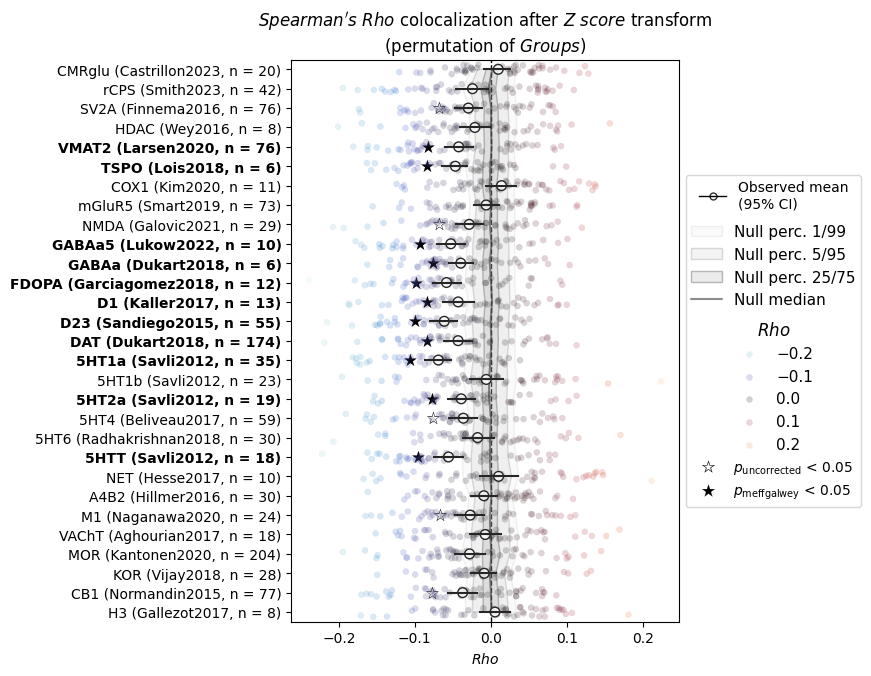

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization after $Z\\ score$ transform\n(permutation of $Groups$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x308ecbf70>)

In [11]:
# plot
nsp_indiv.plot()

## Dimensionality reduction with `reduce_x()`

When you have many reference maps (30 PET tracers, thousands of genes), interpreting individual colocalizations can be difficult — and many maps are correlated with each other. `reduce_x()` summarizes the reference maps into a smaller set of components using PCA, ICA, or factor analysis.

After reduction, `colocalize()` operates on the components instead of individual maps.

In [12]:
# reduce the PET maps to their principal components
nsp.reduce_x("pca", n_components=5)  # keep 5 components

# colocalize on the reduced space
nsp.colocalize("spearman", X_reduction="pca")
nsp.permute("maps", n_perm=1000, X_reduction="pca")

pca_colocs = nsp.get_colocalizations(X_reduction="pca")
print(f"PCA colocalizations: {pca_colocs.shape[0]} disorders x {pca_colocs.shape[1]} components")
pca_colocs

INFO | 20/07/26 18:26:04 | nispace.core.reduce_x: Performing dimensionality reduction using pca (max components: 5, min EV: None).


INFO | 20/07/26 18:26:04 | nispace.core.reduce_x: Returning 5 principal component(s).


Colocalizing (spearman, 4 proc): 100%|████████████████████████████████████████████████| 16/16 [00:00<00:00, 1378.23it/s]

INFO | 20/07/26 18:26:04 | nispace.core.permute: Found existing null maps.


WARNING | 20/07/26 18:26:04 | nispace.core.permute: 5 map(s) missing from null map cache. Will re-generate.


...

Processing null arrays (4 proc): 100%|████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8554.83it/s]

Null colocalizations (spearman, 4 proc): 100%|███████████████████████████████████| 1000/1000 [00:00<00:00, 11437.07it/s]

INFO | 20/07/26 18:26:05 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


PCA colocalizations: 16 disorders x 5 components


,c0,c1,c2,c3,c4
map,,,,,
dx-mdd_age-adult_pub-schmaal2017,0.360650,-0.211170,-0.454443,0.068659,-0.018488
dx-adhd_age-allages_pub-hoogman2019,-0.057997,-0.345816,-0.293569,-0.121616,0.010564
dx-asd_pub-vanrooij2018,-0.395074,0.118303,0.152678,-0.104318,0.226515
dx-bd_age-adult_pub-hibar2018,0.457589,-0.501677,0.253697,-0.131245,0.081823
dx-scz_pub-vanerp2018,0.166803,-0.478120,0.308127,0.002171,0.157909
dx-ocd_age-adult_pub-boedhoe2018,0.496552,-0.134681,-0.072331,-0.268401,-0.244831
dx-epilepsy_pub-whelan2018,-0.197575,-0.074140,0.351701,-0.319496,0.104093
dx-epilepsy_subtype-gge_pub-whelan2018,-0.077951,-0.009747,0.247212,-0.396098,0.093179
dx-epilepsy_subtype-ltle_pub-whelan2018,-0.272236,-0.061233,0.273404,-0.371563,0.086673


INFO | 20/07/26 18:26:05 | nispace.plotting: Significance annotation: 1/5 p_uncorrected < 0.05, 0/5 p_meffgalwey < 0.05 (no correction applied)


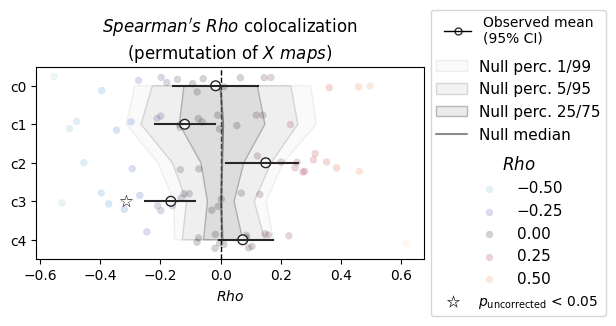

(<Figure size 500x250 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x33bd1c880>)

In [13]:
nsp.plot(X_reduction="pca")

## Alternative colocalization methods

Spearman correlation is the default, but NiSpace supports several other methods. Each has different assumptions and use cases.  

Importantly, methods might return multiple different colocalization metrics. For example, a linear regression model (`"mlr"`) already returns both beta coefficients (one for each X map, as for correlations) **and** the R^2 value (one across X maps). Each of these colocalization statistics will furthermore have an associated p values after `.permute()` has been run.

In [14]:
# set up a simple analysis for comparison
nsp_methods = NiSpace(
    x=rsn17_maps,
    y=enigma_thick.loc[["dx-bd_age-adult_pub-hibar2018"]],  # just bipolar disorder for clarity
    parcellation="DesikanKilliany",
    seed=42
)
nsp_methods.fit()

# Pearson correlation
nsp_methods.colocalize("pearson")
pearson = nsp_methods.get_colocalizations()
print("Pearson:", pearson.values.squeeze())
print("")

# Multiple linear regression (MLR)
nsp_methods.colocalize("mlr")
mlr = nsp_methods.get_colocalizations()
print("MLR beta:", mlr["beta"].values.squeeze())
print("MLR R2:", mlr["r2"].values.squeeze())
print("")

# Partial least squares (PLS)
nsp_methods.colocalize("pls", n_components=3)
pls = nsp_methods.get_colocalizations()
print("PLS beta:", pls["beta"].values.squeeze())
print("PLS R2:", pls["r2"].values.squeeze())
print("")

# Dominance analysis (takes the longest)
nsp_methods.colocalize("dominance")
dom = nsp_methods.get_colocalizations()
print("Dominance: sum (matches MLR R2) :", dom["sum"].values.squeeze())
print("Dominance: total (sum of total is MLR R2):", dom["total"].values.squeeze())
print("Dominance: individual (like a leave-one-out MLR R2):", dom["individual"].values.squeeze())
print("Dominance: relative (fraction of sum R2):", dom["relative"].values.squeeze())


INFO | 20/07/26 18:26:05 | nispace.core.parcellation: Building cortex Parcellation for 'DesikanKilliany' from library. DOI: 10.1016/j.neuroimage.2006.01.021


INFO | 20/07/26 18:26:05 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:26:06 | nispace.core.parcellation: Parcellation 'DesikanKilliany': validation passed.


INFO | 20/07/26 18:26:06 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


INFO | 20/07/26 18:26:06 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


...

MLR beta: [ 0.06792119 -0.01860249  0.0106711   0.0244113   0.03303479  0.04273786
  0.02695448  0.04961617 -0.00843902  0.00987888  0.0057653   0.02717505
  0.06151685  0.03901247 -0.01884886  0.09041714  0.04204404]
MLR R2: 0.08892989



Colocalizing (pls, 1 proc): 100%|████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 102.95it/s]

PLS beta: [ 2.0041761e-03 -1.6259542e-02 -2.2138054e-02  1.6468605e-04
  7.5916052e-03 -9.2356192e-04  1.4484321e-03  7.4772104e-03
  2.1116403e-03 -1.3464274e-02  1.3941166e-03 -3.1699201e-03
  8.5434360e-05  2.4655869e-03 -3.0783098e-02  2.0868970e-02
  8.5071260e-03]
PLS R2: 0.5273024



Colocalizing (dominance, 1 proc): 100%|███████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.31s/it]

Dominance: sum (matches MLR R2) : -5.6413383
Dominance: total (sum of total is MLR R2): [-0.3582054  -0.253004   -0.26643303 -0.36372048 -0.34428048 -0.35236186
 -0.36082304 -0.346657   -0.36318967 -0.31780437 -0.36006957 -0.34669048
 -0.35836783 -0.3574694  -0.26711085 -0.28469688 -0.34045407]
Dominance: individual (like a leave-one-out MLR R2): [-0.01113302  0.2559675   0.18881793 -0.01484976  0.01296868  0.02458442
 -0.00317526  0.01919597 -0.01282031  0.08868193 -0.01276945  0.03920722
  0.00426024  0.00798787  0.03959062  0.13981932  0.00341059]
Dominance: relative (fraction of sum R2): [0.06349653 0.04484822 0.04722869 0.06447414 0.06102816 0.06246068
 0.06396054 0.06144943 0.06438005 0.05633492 0.06382698 0.06145536
 0.06352532 0.06336606 0.04734884 0.05046619 0.06034987]


If we plot multi-outcome colocalization results, we will automatically get one plot for each metric. E.g., for the quite detailled dominance output:

INFO | 20/07/26 18:26:11 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 20/07/26 18:26:11 | nispace.core.permute: Generating null maps (n = 1000, null_method = 'moran').


INFO | 20/07/26 18:26:11 | nispace.nulls: Null map generation: Assuming n = 17 data vector(s) for n = 68 parcels.


INFO | 20/07/26 18:26:11 | nispace.nulls: Using provided distance matrix/matrices.


Moran null maps (4 proc): 100%|████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 152.27it/s]

INFO | 20/07/26 18:26:11 | nispace.nulls: Null data generation finished.


INFO | 20/07/26 18:26:11 | nispace.core.permute: Z-standardizing null maps.


Null colocalizations (pls, 4 proc): 100%|████████████████████████████████████████| 1000/1000 [00:00<00:00, 20119.85it/s]

INFO | 20/07/26 18:26:11 | nispace.core.permute: Calculating exact p-values (tails = {'r2': 'upper', 'beta': 'two'}).


INFO | 20/07/26 18:26:11 | nispace.plotting: Significance annotation: 0/1 p_uncorrected < 0.05, 0/1 p_meffgalwey < 0.05


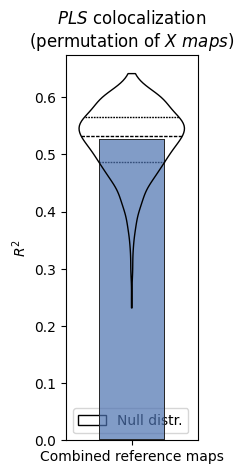

INFO | 20/07/26 18:26:12 | nispace.plotting: Significance annotation: 1/17 p_uncorrected < 0.05, 0/17 p_meffgalwey < 0.05


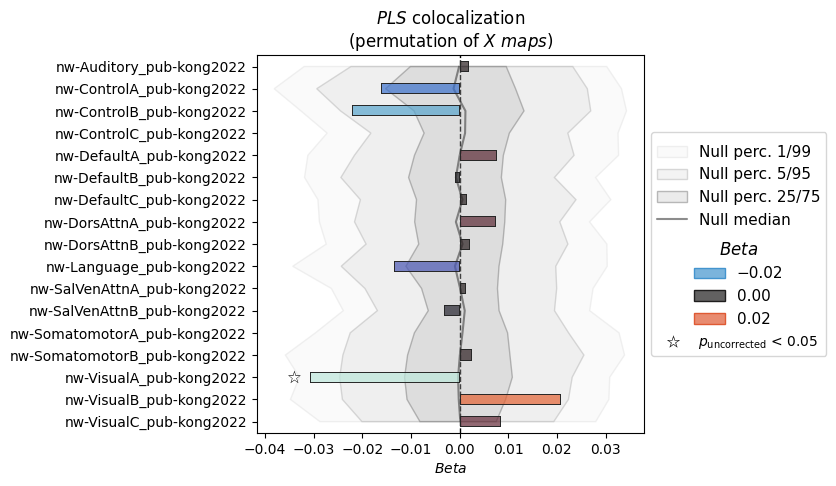

{'r2': (<Figure size 170x500 with 1 Axes>,
  <Axes: title={'center': '$PLS$ colocalization\n(permutation of $X\\ maps$)'}, ylabel='$R^2$'>,
  <seaborn._core.plot.Plotter at 0x3438afd30>),
 'beta': (<Figure size 500x490 with 1 Axes>,
  <Axes: title={'center': '$PLS$ colocalization\n(permutation of $X\\ maps$)'}, xlabel='$Beta$'>,
  <seaborn._core.plot.Plotter at 0x34364fe50>)}

In [15]:
# first: run the proper permutation; will take some time for dominance analysis
nsp_methods.permute("maps", method="pls", n_perm=1000, n_proc=4)
nsp_methods.correct_p(coloc_method="pls")

# show
nsp_methods.plot()

## Summary

| Feature | How to use |
|---------|------------|
| Individual-level colocalization | `nsp.colocalize()` + `nsp.permute(pooled_p=False)` |
| Individual-level deviation colocalization | `nsp.transform_y("zscore(a,b)", groups=...)` + `nsp.colocalize()` + `nsp.permute("groups")` |
| Dimensionality reduction | `nsp.reduce_x("pca", n_components=5)`, then `nsp.colocalize(..., X_reduction="pca")` |
| Alternative colocalization methods | `nsp.colocalize("partialpearson")`, `"pls"`, `"ridge"`, etc. |

This is the last notebook in the introduction series. For more, see the [API reference](../api_ref.rst) and the [Example notebooks](../examples.rst).